# Save point map

In [6]:
import numpy as np

npz_file = 'results/poses_logs/1.0.npz'
npz_data = np.load(npz_file)

pointcloud = npz_data['pointcloud']
mask = npz_data['mask']
print(pointcloud.shape)
print(mask.shape)

(294, 518, 3)
(294, 518)


In [9]:
def save_pointcloud_to_ply(filename, pointcloud, mask=None):
    points = pointcloud.reshape(-1, 3)
    
    # if mask is not None:
    #     mask_flat = mask.flatten()
    #     points = points[mask_flat]
        
    with open(filename, 'w') as f:
        f.write('ply\n')
        f.write('format ascii 1.0\n')
        f.write(f'element vertex {len(points)}\n')
        f.write('property float x\n')
        f.write('property float y\n')
        f.write('property float z\n')
        f.write('end_header\n')
        for p in points:
            f.write(f'{p[0]} {p[1]} {p[2]}\n')

save_pointcloud_to_ply('results/pointcloud.ply', pointcloud, mask)

# Result poses

In [1]:
import numpy as np

### TUM
# res_file = 'results/tum/rgbd_dataset_freiburg1_360/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_desk/poses_no_flow_downsample.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_desk/poses2.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_desk2/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_floor/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_plant/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_room/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_rpy/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_teddy/poses2.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_xyz/poses.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_xyz/poses2.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_xyz/poses_no_opt.txt'
# res_file = 'results/tum/rgbd_dataset_freiburg1_xyz/poses2_no_flow_downsample.txt'


### EuRoC
# res_file = 'results/euroc/MH_01_easy/poses.txt'
# res_file = 'results/euroc/MH_02_easy/poses.txt'
# res_file = 'results/euroc/MH_03_medium/poses.txt'
# res_file = 'results/euroc/V1_01_easy/poses.txt'
# res_file = 'results/euroc/V1_02_medium/poses.txt'
# res_file = 'results/euroc/V2_02_medium/poses.txt'
# res_file = 'results/euroc/V2_03_difficult/poses.txt'


### Waymo
# res_file = 'results/waymo/13476/poses.txt'
# res_file = 'results/waymo/100613/poses.txt'
# res_file = 'results/waymo/106762/poses.txt'
# res_file = 'results/waymo/132384/poses.txt'


### 7-scenes
# res_file = 'results/7scenes/chess/poses.txt'
# res_file = 'results/7scenes/fire/poses.txt'
# res_file = 'results/7scenes/heads/poses.txt'
# res_file = 'results/7scenes/office/poses.txt'
# res_file = 'results/7scenes/pumpkin/poses.txt'
# res_file = 'results/7scenes/redkitchen/poses.txt'
res_file = 'results/7scenes/stairs/poses.txt'


res_data = np.loadtxt(res_file, delimiter=" ", dtype=np.str_, skiprows=0)
pose_vecs = res_data[:, 0:].astype(np.float64)
print(f'pose_vecs.shape: {pose_vecs.shape}')

pose_vecs.shape: (14, 8)


In [2]:
import trimesh

poses_est = []
stamps_est = []

for k in range(len(pose_vecs)):
    # ======================================
    # stamp = pose_vecs[k][0]
    stamp = int(pose_vecs[k][0])  ### waymo, 7-scenes, int timestamp
    # ======================================
    stamps_est.append(stamp)
    
    quat = pose_vecs[k][4:]
    trans = pose_vecs[k][1:4]
    T = trimesh.transformations.quaternion_matrix(np.roll(quat, 1))
    T[:3, 3] = trans
    
    poses_est.append(T)

# GT poses TUM, EuRoC, 7-scenes

In [3]:
import numpy as np

### TUM
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_360/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_desk/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_desk2/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_floor/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_plant/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_room/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_rpy/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_teddy/groundtruth.txt'
# gt_file = '/home/grl/datasets/tum/rgbd_dataset_freiburg1_xyz/groundtruth.txt'

### EuRoC
# gt_file = '/home/grl/datasets/euroc/groundtruths/MH_01_easy.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/MH_02_easy.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/MH_03_medium.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/V1_01_easy.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/V1_02_medium.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/V2_02_medium.txt'
# gt_file = '/home/grl/datasets/euroc/groundtruths/V2_03_difficult.txt'

### 7-scenes
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/chess.txt'
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/fire.txt'
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/heads.txt'
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/office.txt'
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/pumpkin.txt'
# gt_file = '/home/grl/datasets/7-scenes/groundtruths/redkitchen.txt'
gt_file = '/home/grl/datasets/7-scenes/groundtruths/stairs.txt'


# gt_data = np.loadtxt(gt_file, delimiter=" ", dtype=np.str_, skiprows=3)  ### tum
gt_data = np.loadtxt(gt_file, delimiter=" ", dtype=np.str_, skiprows=0)  ### euroc, 7-scenes
pose_vecs = gt_data[:, 0:].astype(np.float64)
print(f'pose_vecs.shape: {pose_vecs.shape}')

pose_vecs.shape: (500, 8)


In [4]:
import trimesh

poses_gt = []
stamps_gt = []

for k in range(len(pose_vecs)):
    stamp = pose_vecs[k][0]
    stamps_gt.append(stamp)
    
    quat = pose_vecs[k][4:]
    trans = pose_vecs[k][1:4]
    T = trimesh.transformations.quaternion_matrix(np.roll(quat, 1))
    T[:3, 3] = trans
    
    poses_gt.append(T)

In [5]:
# Find the closest gt pose for each estimated stamp
stamps_gt_selected = []
poses_gt_selected = []

for stamp_est in stamps_est:
    idx = np.argmin(np.abs(np.array(stamps_gt) - stamp_est))
    stamps_gt_selected.append(stamps_gt[idx])
    poses_gt_selected.append(poses_gt[idx])
    
print(len(poses_gt_selected))
print(len(poses_est))

print(len(stamps_gt_selected))
print(len(stamps_est))

14
14
14
14


# GT poses Waymo

In [15]:
import numpy as np
import os

# gt_folder ='/home/grl/datasets/waymo/13476/FRONT/gt'
# gt_folder ='/home/grl/datasets/waymo/100613/FRONT/gt'
# gt_folder ='/home/grl/datasets/waymo/106762/FRONT/gt'
gt_folder ='/home/grl/datasets/waymo/132384/FRONT/gt'


gt_files = [f for f in os.listdir(gt_folder)]
gt_files.sort()

In [16]:
poses_gt = []
for gt_file in gt_files:
    pose = np.loadtxt(os.path.join(gt_folder, gt_file))
    # poses_gt.append(np.linalg.inv(pose))
    poses_gt.append(pose)
    
print(f'len(poses_gt): {len(poses_gt)}')

len(poses_gt): 199


In [17]:
# Find the closest gt pose for each estimated stamp
poses_gt_selected = []

for idx in stamps_est:
    poses_gt_selected.append(poses_gt[idx])
print(f'len(poses_gt_selected): {len(poses_gt_selected)}')

TypeError: list indices must be integers or slices, not numpy.float64

# EVO

In [6]:
from evo.core.trajectory import PosePath3D
from evo.core import metrics

## Align
traj_ref = PosePath3D(poses_se3=poses_gt_selected)
traj_est = PosePath3D(poses_se3=poses_est)

r_a, t_a, s = traj_est.align(traj_ref, correct_scale=True)
traj_est_aligned = traj_est

## ATE RMSE
pose_relation = metrics.PoseRelation.translation_part
data = (traj_ref, traj_est_aligned)

ape_metric = metrics.APE(pose_relation)
ape_metric.process_data(data)
ape_rmse = ape_metric.get_statistic(metrics.StatisticsType.rmse)
ape_stats = ape_metric.get_all_statistics()
# ape_stats['scale'] = s
print(f"RMSE ATE (m): {ape_rmse}, scale: {s}")

RMSE ATE (m): 0.09472688387711622, scale: 3.074144751011467


In [7]:
from evo.tools import plot
from matplotlib import pyplot as plt
import os

## Plot
# plot_mode = plot.PlotMode.xy
plot_mode = plot.PlotMode.xyz
fig = plt.figure()

ax = plot.prepare_axis(fig, plot_mode)
ax.set_title(f"ATE RMSE: {ape_rmse:.3f}, scale: {s:.3f}")
plot.traj(ax, plot_mode, traj_ref, "--", "gray", "gt")

plot.traj_colormap(
    ax,
    traj_est_aligned,
    ape_metric.error,
    plot_mode,
    min_map=ape_stats["min"],
    max_map=ape_stats["max"],
)
ax.legend()
# plt.show()

fig_dir = os.path.dirname(res_file)

fig_path = os.path.join(fig_dir, "aligned_trajectory.png")
# fig_path = os.path.join(fig_dir, "aligned_trajectory_no_flow_downsample.png")

fig.savefig(fig_path, dpi=300, bbox_inches='tight')

# Loop closure (ImageRetrieval)

In [1]:
from PIL import Image
from torchvision import transforms as TF
import torch

image_paths = [
    'test/1305031102.175304.png',
    'test/1305031123.751723.png',
]
imgs = []
for path in image_paths:
    img = TF.ToTensor()(Image.open(path).convert('RGB'))
    imgs.append(img)
imgs = torch.stack(imgs)

In [2]:
print(f"imgs size: {imgs.shape}")

imgs size: torch.Size([2, 3, 480, 640])


In [3]:
from vggt_slam.loop_closure import ImageRetrieval

image_retrieval = ImageRetrieval()
retrieval_vector = image_retrieval.get_batch_descriptors(imgs)
print(f"retrieval_vector size: {retrieval_vector.shape}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.
Loading ImageRetrieval model from checkpoints/dino_salad.ckpt...


Using cache found in /home/grl/.cache/torch/hub/facebookresearch_dinov2_main
/home/grl/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/grl/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/grl/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Loaded model from checkpoints/dino_salad.ckpt Successfully!
retrieval_vector size: torch.Size([2, 8448])


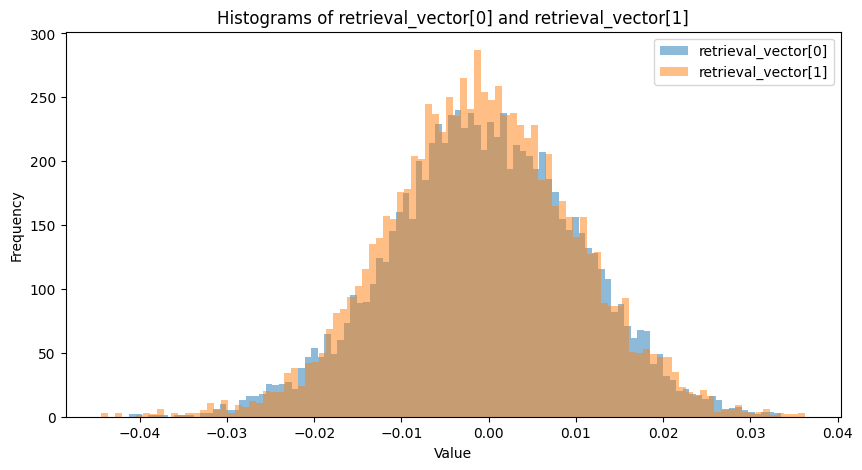

In [4]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(retrieval_vector[0].cpu().numpy(), bins=100, alpha=0.5, label='retrieval_vector[0]')
plt.hist(retrieval_vector[1].cpu().numpy(), bins=100, alpha=0.5, label='retrieval_vector[1]')
plt.legend()
plt.title('Histograms of retrieval_vector[0] and retrieval_vector[1]')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [5]:
v0 = retrieval_vector[0]
v1 = retrieval_vector[1]
score = torch.linalg.norm(v0 - v1)
print(f'score: {score}')

score: 0.9754155874252319


# 0